<a href="https://colab.research.google.com/github/willow788/one-model-a-week-keeps-the-fomo-away/blob/main/textClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score

In [32]:
df = pd.read_csv('/synthetic_text_data.csv')
X = df['text']
y = df['label']
df.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [23]:
#spliting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
vectorizer = CountVectorizer()
X_train_vectorised = vectorizer.fit_transform(X_train)
X_test_vectorised = vectorizer.fit_transform(X_test)

In [25]:
vectorizer = TfidfVectorizer()
X_train_vectorised = vectorizer.fit_transform(X_train)
X_test_vectorised = vectorizer.transform(X_test)

#will use multinomial bayes model
model = MultinomialNB()
model.fit(X_train_vectorised, y_train)

y_pred = model.predict(X_test_vectorised)

In [28]:
#evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy * 100}%')

Accuracy: 76.47058823529412%


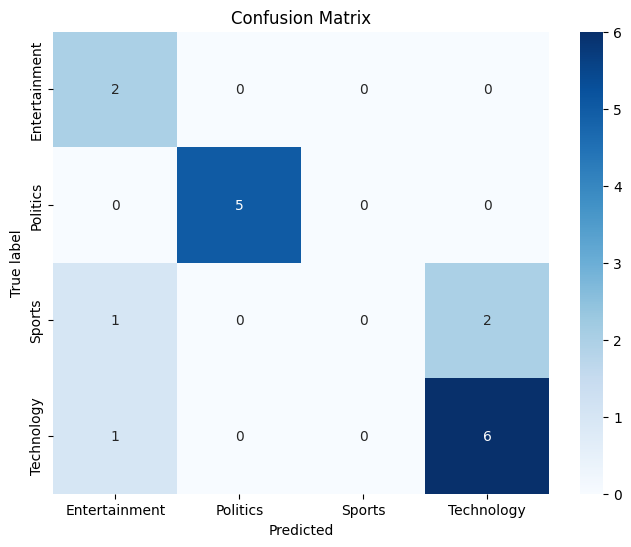

In [29]:
class_labels = np.unique(y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True label')
plt.show()

In [30]:
#predicting on unseen data
unseen_data = ("I am that ex girlfriend of aditya everybody's talking about")
unseen_Data_vec = vectorizer.transform([unseen_data])
prediction = model.predict(unseen_Data_vec)
print(f"Prediction: {prediction[0]} category")

Prediction: Entertainment category


In [31]:
another_Data = ("we had a baby last week"
)
another_data_vec = vectorizer.transform([another_Data])
prediction = model.predict(another_data_vec)
print(f"prediction: {prediction[0]} category")

prediction: Technology category
